# 🚀 TechNova Retail & Customer Churn

<div dir="rtl" style="text-align: right;>

**مرحبًا بيك في مشروع TechNova! 🎉**

النوت بوك دي هي الدليل الكامل بتاعك لليوم الخامس من الـ Bootcamp. هنعمل فيها الآتي:

1. 🧹 **تنظيف البيانات** — هنصلح القيم المفقودة والأخطاء في الداتا.
2. 📊 **استكشاف البيانات (EDA)** — هنرسم رسومات بيانية احترافية عشان نفهم الداتا.
3. ⚙️ **هندسة الميزات (Feature Engineering)** — هنحضر الداتا للموديل.
4. 🤖 **تدريب موديل ML** — هنبني Logistic Regression ونحسّنه.
5. 💾 **حفظ الموديل** — هنحفظه بـ `joblib` عشان نستخدمه في الـ Streamlit App.

</div>

<div dir="rtl" style="text-align: right; font-size: 18px; line-height: 2;

### 📦 استيراد المكتبات (Importing Libraries)
أول حاجة بنعملها في أي مشروع بايثون هي إننا نستورد المكتبات اللي هنحتاجها. كل مكتبة ليها وظيفة معينة:
- **pandas**: للتعامل مع البيانات في جداول (DataFrames)
- **numpy**: للعمليات الحسابية
- **matplotlib & seaborn**: للرسم البياني
- **sklearn**: لبناء موديلات الـ Machine Learning

</div>

In [2]:
# ============================================================
# IMPORTING LIBRARIES
# ============================================================
# pandas: Data manipulation and analysis (DataFrames)
# numpy: Numerical computing (arrays, math operations)
# matplotlib & seaborn: Data visualization libraries
# sklearn: Machine Learning library (model training, evaluation, preprocessing)
# joblib: Model serialization (save/load trained models)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                             classification_report, roc_auc_score, roc_curve)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set global visualization style for professional-looking charts
sns.set_theme(style="whitegrid", palette="viridis", font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


<div dir="rtl" style="text-align: right; font-size: 18px; line-height: 2;">

### 📂 تحميل البيانات (Loading the Data)
هنا بنحمّل ملف الـ CSV اللي فيه الداتا الخام بتاعتنا. الداتا دي فيها **مشاكل متعمّدة** (قيم مفقودة، أسماء غلط، أعمار غريبة) عشان نتعلم إزاي ننضفها.

خلّي بالك من:
- عمود `Cost` فيه قيم فاضية (NaN)
- عمود `Discount` فيه قيم فاضية
- عمود `Category` فيه أسماء مختصرة غلط زي "Elec" بدل "Electronics"
- عمود `FullName` فيه أسماء بحروف كبيرة ومسافات زيادة

</div>

In [3]:
# ============================================================
# LOADING THE RAW DATASET
# ============================================================
# Read the CSV file into a pandas DataFrame
# This is the "messy" data that simulates real-world data quality issues
df = pd.read_csv('dataset_raw.csv')

# Display basic information about the dataset
print(f"📏 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n📋 Column Names:\n{list(df.columns)}")
print(f"\n❓ Missing Values per Column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Preview the first 5 rows
df.head()

📏 Dataset Shape: 5000 rows × 18 columns

📋 Column Names:
['CustomerID', 'FullName', 'Age', 'City', 'JoinDate', 'Churn', 'OrderID', 'OrderDate', 'ShipMode', 'ProductID', 'ProductName', 'Category', 'Price', 'Cost', 'Quantity', 'Discount', 'Days_Since_Last_Order', 'Total_Orders']

❓ Missing Values per Column:
Cost         250
Discount    3532
dtype: int64


,CustomerID,FullName,Age,City,JoinDate,Churn,OrderID,OrderDate,ShipMode,ProductID,ProductName,Category,Price,Cost,Quantity,Discount,Days_Since_Last_Order,Total_Orders
0,2126,CUSTOMER_0,35,Mansoura,02-08-2023,0,11420,02-08-2023,Same Day,135,Product_135,Home Appliances,712.82,334.36,1,NaN,518,4
1,2459,Customer_1,54,Cairo,08/16/2020,0,12597,08/16/2020,Express,119,Product_119,Home Appliances,148.60,76.56,2,0.05,661,6
2,1860,Customer_2,60,Mansoura,02/21/2020,1,10496,02/21/2020,Same Day,113,Product_113,Clothing,1039.74,640.86,1,0.05,1094,3
3,2294,Customer_3,17,Cairo,07/17/2021,0,12220,07/17/2021,Same Day,105,Product_105,Electronics,117.63,57.56,3,NaN,673,5
4,2130,Customer_4,32,Luxor,16-05-2021,0,10104,16-05-2021,Express,144,Product_144,Electronics,413.23,274.34,5,NaN,349,4


<div dir="rtl" style="text-align: right; font-size: 18px; line-height: 2; border-radius: 10px;>

### 🧹 تنظيف البيانات (Data Cleaning)
دي أهم خطوة في أي مشروع داتا! الداتا الخام دايمًا بتيجي فيها مشاكل، وإحنا لازم نصلحها قبل ما نعمل أي تحليل.

**اللي هنعمله:**
- 🔤 **تنظيف الأسماء**: نشيل المسافات الزيادة ونخلي أول حرف كبير (`strip().title()`)
- 💰 **ملء القيم الفاضية في `Cost`**: هنستخدم الـ Median (الوسيط) بدل الـ Mean عشان الـ Median مش بيتأثر بالقيم المتطرفة
- 🏷️ **ملء القيم الفاضية في `Discount`**: لو الخصم فاضي، يبقى مفيش خصم = 0
- 📦 **تصحيح أسماء الفئات**: "Elec" و "elect" → "Electronics"
- 💵 **حساب `Revenue` و `Profit`**: هندسة ميزات جديدة من البيانات الموجودة

</div>

In [4]:
# ============================================================
# DATA CLEANING
# ============================================================

# 1. Clean customer names: remove extra spaces and fix capitalization
#    Example: "  CUSTOMER_0  " → "Customer_0"
df['FullName'] = df['FullName'].astype(str).str.strip().str.title()

# 2. Fill missing Cost values with the median (robust to outliers)
cost_median = df['Cost'].median()
print(f"📊 Cost Median (used for imputation): ${cost_median:.2f}")
df['Cost'] = df['Cost'].fillna(cost_median)

# 3. Fill missing Discount values with 0 (no discount = 0%)
df['Discount'] = df['Discount'].fillna(0)

# 4. Fix inconsistent Category names
#    "Elec" and "elect" should both be "Electronics"
df['Category'] = df['Category'].replace({'Elec': 'Electronics', 'elect': 'Electronics'})

# 5. Calculate Revenue and Profit (Feature Engineering)
#    Revenue = Price × Quantity × (1 - Discount)
#    Profit  = Revenue - (Cost × Quantity)
df['Revenue'] = df['Price'] * df['Quantity'] * (1 - df['Discount'])
df['Profit'] = df['Revenue'] - (df['Cost'] * df['Quantity'])

# Verify: no more missing values in critical columns
print(f"\n✅ Missing values after cleaning:")
print(df[['Cost', 'Discount', 'Category', 'Revenue', 'Profit']].isnull().sum())
print(f"\n📋 Unique Categories: {df['Category'].unique()}")
df[['FullName', 'Cost', 'Discount', 'Category', 'Revenue', 'Profit']].head()

📊 Cost Median (used for imputation): $429.51

✅ Missing values after cleaning:
Cost        0
Discount    0
Category    0
Revenue     0
Profit      0
dtype: int64

📋 Unique Categories: ['Home Appliances' 'Clothing' 'Electronics' 'Sports']


,FullName,Cost,Discount,Category,Revenue,Profit
0,Customer_0,334.36,0.00,Home Appliances,712.820,378.460
1,Customer_1,76.56,0.05,Home Appliances,282.340,129.220
2,Customer_2,640.86,0.05,Clothing,987.753,346.893
3,Customer_3,57.56,0.00,Electronics,352.890,180.210
4,Customer_4,274.34,0.00,Electronics,2066.150,694.450


<div dir="rtl" style="text-align: right; font-size: 18px; line-height: 2;">

### 📊 استكشاف البيانات — توزيع الـ Churn (Class Imbalance)
أول حاجة بنبص عليها هي: **كام عميل ساب الشركة (Churned) وكام عميل لسه موجود (Active)؟**

لو الفرق كبير بين الاتنين، ده اسمه **Class Imbalance** — وده بيأثر على أداء الموديل بتاعنا. عشان كده هنستخدم `class_weight='balanced'` لما نبني الموديل.

</div>

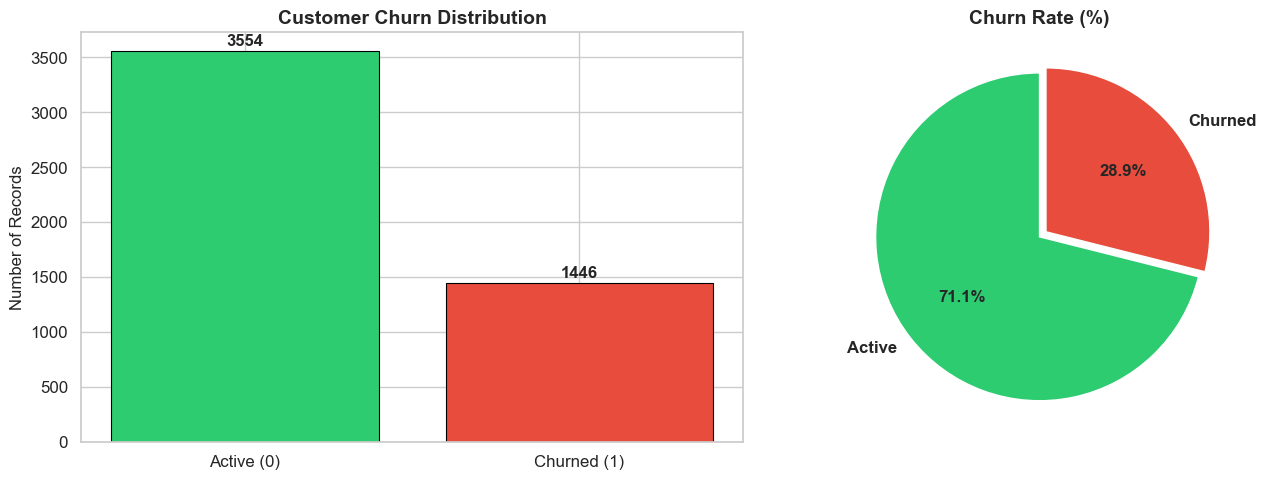

📊 Churn Rate: 28.9%


In [5]:
# ============================================================
# EDA: CHURN CLASS DISTRIBUTION
# ============================================================
# Visualize the distribution of churned vs. active customers
# This helps us understand if the classes are balanced or imbalanced

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Count plot showing raw numbers
colors = ['#2ecc71', '#e74c3c']  # Green for Active, Red for Churned
churn_counts = df['Churn'].value_counts()
axes[0].bar(['Active (0)', 'Churned (1)'], churn_counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Records', fontsize=12)
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=12)

# Right: Pie chart showing percentages
axes[1].pie(churn_counts.values, labels=['Active', 'Churned'], autopct='%1.1f%%', 
            colors=colors, startangle=90, explode=(0, 0.05),
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Churn Rate (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
print(f"📊 Churn Rate: {churn_counts[1] / len(df) * 100:.1f}%")

<div dir="rtl" style="text-align: right; font-size: 18px; line-height: 2;">

### 📈 تأثير العمر على الـ Churn
هل العملاء الأكبر سنًا بيسيبوا الشركة أكتر؟ ولا الصغيرين؟ هنستخدم **Box Plot** و **Histogram** عشان نشوف التوزيع.

**ملحوظة مهمة**: الداتا الخام فيها أعمار غريبة (زي -5 أو 200 سنة) — دي قيم متطرفة (Outliers) بنفلترها عشان الرسمة تطلع مظبوطة.

</div>

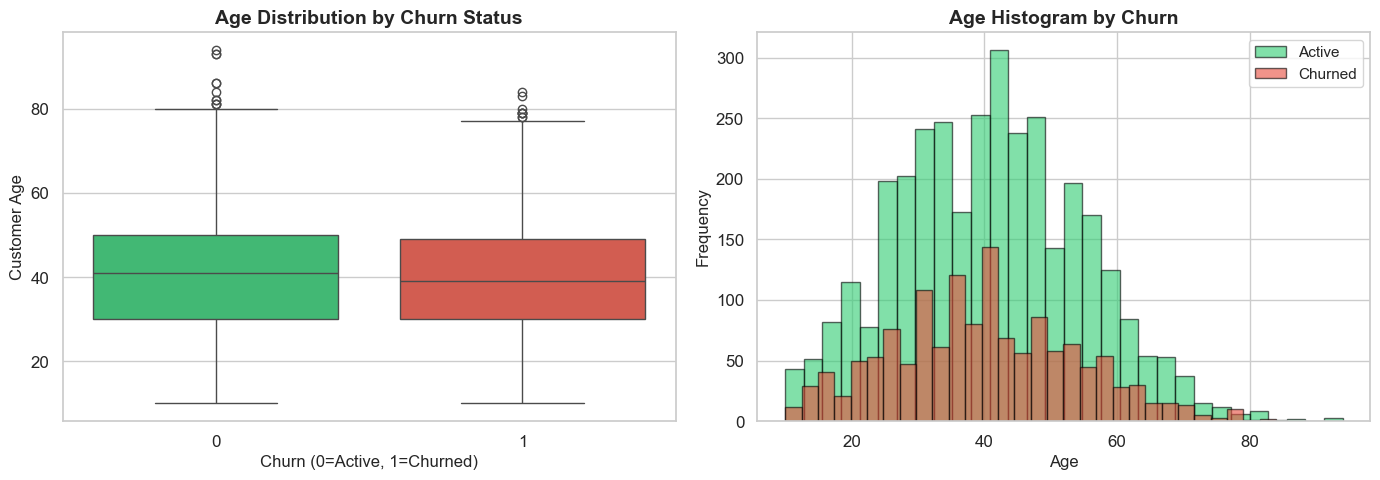

In [6]:
# ============================================================
# EDA: AGE DISTRIBUTION BY CHURN STATUS
# ============================================================
# Filter out impossible/outlier ages for visualization clarity
df_valid_age = df[(df['Age'] >= 10) & (df['Age'] <= 100)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Box plot — shows median, quartiles, and outliers
sns.boxplot(x='Churn', y='Age', data=df_valid_age, ax=axes[0],
            hue='Churn', palette={0: '#2ecc71', 1: '#e74c3c'}, legend=False)
axes[0].set_title('Age Distribution by Churn Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn (0=Active, 1=Churned)', fontsize=12)
axes[0].set_ylabel('Customer Age', fontsize=12)

# Right: Overlapping histograms — shows the full distribution shape
axes[1].hist(df_valid_age[df_valid_age['Churn'] == 0]['Age'], bins=30, alpha=0.6, 
             label='Active', color='#2ecc71', edgecolor='black')
axes[1].hist(df_valid_age[df_valid_age['Churn'] == 1]['Age'], bins=30, alpha=0.6, 
             label='Churned', color='#e74c3c', edgecolor='black')
axes[1].set_title('Age Histogram by Churn', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right; font-size: 18px; line-height: 2;">

### 💰 تحليل الإيرادات حسب الفئة (Revenue by Category)
هنا بنشوف أنهي فئة منتجات بتجيب أكتر فلوس. ده بيساعد فريق التسويق يعرف يركز على إيه.

</div>

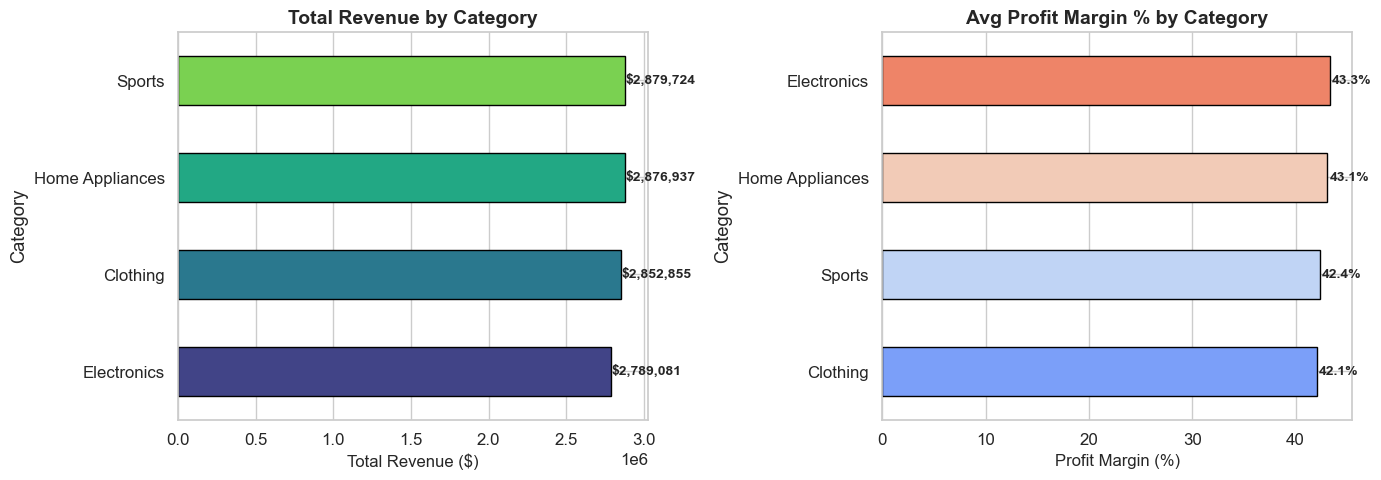

In [7]:
# ============================================================
# EDA: REVENUE & PROFIT BY CATEGORY
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Total Revenue by Category
cat_revenue = df.groupby('Category')['Revenue'].sum().sort_values(ascending=True)
cat_revenue.plot(kind='barh', ax=axes[0], color=sns.color_palette('viridis', len(cat_revenue)), edgecolor='black')
axes[0].set_title('Total Revenue by Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Revenue ($)', fontsize=12)
# Add value labels on bars
for i, (val, name) in enumerate(zip(cat_revenue.values, cat_revenue.index)):
    axes[0].text(val + 1000, i, f'${val:,.0f}', va='center', fontweight='bold', fontsize=10)

# Right: Average Profit Margin by Category
cat_margin = df.groupby('Category').apply(lambda x: (x['Profit'].sum() / x['Revenue'].sum()) * 100).sort_values()
cat_margin.plot(kind='barh', ax=axes[1], color=sns.color_palette('coolwarm', len(cat_margin)), edgecolor='black')
axes[1].set_title('Avg Profit Margin % by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Profit Margin (%)', fontsize=12)
for i, val in enumerate(cat_margin.values):
    axes[1].text(val + 0.2, i, f'{val:.1f}%', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right; font-size: 18px; line-height: 2;">

### 🔥 خريطة الحرارة (Correlation Heatmap)
الخريطة دي بتوري العلاقة بين كل المتغيرات الرقمية. لو اللون **غامق** (قريب من 1 أو -1) يبقى في علاقة قوية.

ده بيساعدنا نختار أحسن Features للموديل بتاعنا.

</div>

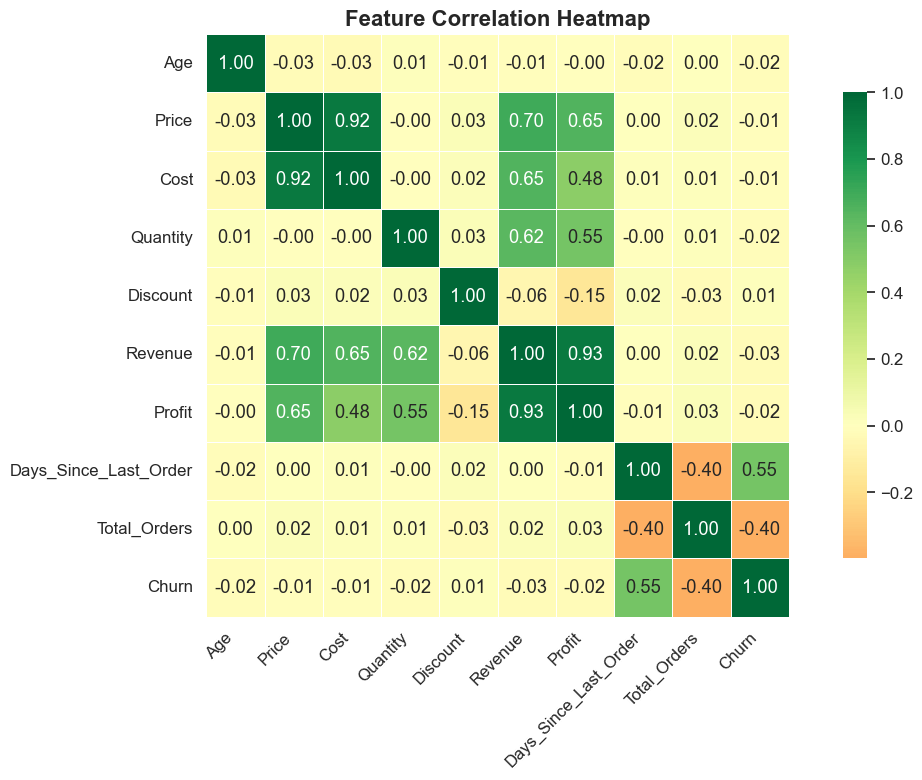

📊 Correlation with Churn (Target Variable):
Churn                    1.000000
Days_Since_Last_Order    0.550774
Discount                 0.010944
Cost                    -0.012299
Price                   -0.014769
Age                     -0.017541
Quantity                -0.017931
Profit                  -0.024129
Revenue                 -0.025283
Total_Orders            -0.397725


In [8]:
# ============================================================
# EDA: CORRELATION HEATMAP
# ============================================================
# Select only numeric columns for correlation analysis
numeric_cols = ['Age', 'Price', 'Cost', 'Quantity', 'Discount', 'Revenue', 'Profit',
                'Days_Since_Last_Order', 'Total_Orders', 'Churn']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print the correlation of each feature with Churn (our target)
print("📊 Correlation with Churn (Target Variable):")
print(corr_matrix['Churn'].sort_values(ascending=False).to_string())

<div dir="rtl" style="text-align: right; font-size: 18px; line-height: 2;">

### ⚙️ هندسة الميزات (Feature Engineering)
الداتا اللي عندنا دلوقتي على مستوى **الطلب** (كل صف = طلب واحد)، بس إحنا عايزين نتوقع الـ Churn على مستوى **العميل** (كل صف = عميل واحد).

عشان كده هنعمل **Group By** على `CustomerID` ونحسب:
- 🎂 **العمر** — أقصى عمر (لأنه ثابت لكل عميل)
- 💵 **إجمالي المصروف** — مجموع كل الإيرادات
- 📉 **متوسط الخصم** — كام في المية بياخد خصم
- 📅 **أيام من آخر طلب** — كل ما يزيد = احتمال الـ Churn يزيد
- 🛒 **عدد الطلبات** — كل ما يزيد = احتمال الـ Churn يقل

</div>

In [9]:
# ============================================================
# FEATURE ENGINEERING: Aggregate to Customer Level
# ============================================================
# The raw data is at the ORDER level (each row = one order line)
# We need to aggregate to the CUSTOMER level (each row = one unique customer)

customer_df = df.groupby('CustomerID').agg(
    Age=('Age', 'max'),                           # Age is constant per customer
    Total_Spent=('Revenue', 'sum'),                # Lifetime revenue
    Avg_Discount=('Discount', 'mean'),             # Average discount received
    Days_Since_Last_Order=('Days_Since_Last_Order', 'max'),  # Recency
    Total_Orders=('Total_Orders', 'max'),           # Frequency
    Avg_Profit=('Profit', 'mean'),                  # Average profit per order
    Churn=('Churn', 'max')                          # Target variable
).reset_index()

# Fix outlier ages: replace impossible values with the median
median_age = customer_df.loc[
    (customer_df['Age'] >= 18) & (customer_df['Age'] <= 100), 'Age'
].median()
customer_df.loc[(customer_df['Age'] < 18) | (customer_df['Age'] > 100), 'Age'] = median_age

print(f"✅ Customer-level dataset: {customer_df.shape[0]} unique customers")
print(f"📊 Features: {list(customer_df.columns)}")
customer_df.head()

✅ Customer-level dataset: 1433 unique customers
📊 Features: ['CustomerID', 'Age', 'Total_Spent', 'Avg_Discount', 'Days_Since_Last_Order', 'Total_Orders', 'Avg_Profit', 'Churn']


,CustomerID,Age,Total_Spent,Avg_Discount,Days_Since_Last_Order,Total_Orders,Avg_Profit,Churn
0,1000,67,7239.956,0.090000,363,5,751.098200,0
1,1001,54,13428.592,0.040000,585,5,1232.700400,0
2,1002,62,4097.643,0.075000,687,4,477.753250,1
3,1003,56,7844.480,0.000000,446,2,1584.840000,0
4,1004,55,1538.094,0.066667,969,3,241.514667,0


<div dir="rtl" style="text-align: right; font-size: 18px; line-height: 2;">

### 🤖 تدريب الموديل (Model Training)
دلوقتي جه الوقت الحقيقي! هنبني موديل **Logistic Regression** مع تحسينات كتير:

1. **Train/Test Split** (80/20) مع `stratify` عشان يحافظ على نسبة الـ Churn في الاتنين
2. **StandardScaler** — بنوحّد مقياس الأرقام عشان الموديل يتعلم أحسن
3. **GridSearchCV** — بنجرب أكتر من تركيبة Hyperparameters ونختار الأحسن
4. **class_weight='balanced'** — بيخلي الموديل يهتم أكتر بالـ Minority Class (اللي عملوا Churn)

</div>

In [10]:
# ============================================================
# MODEL TRAINING: Logistic Regression with Hyperparameter Tuning
# ============================================================

# 1. Define features (X) and target (y)
features = ['Age', 'Total_Spent', 'Days_Since_Last_Order', 'Total_Orders', 'Avg_Discount', 'Avg_Profit']
X = customer_df[features]
y = customer_df['Churn']

# 2. Split data: 80% training, 20% testing
#    stratify=y ensures the churn ratio is preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"🔀 Train set: {X_train.shape[0]} customers | Test set: {X_test.shape[0]} customers")
print(f"📊 Churn ratio in Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")

# 3. Feature Scaling: StandardScaler normalizes features to mean=0, std=1
#    This is critical for Logistic Regression as it uses gradient-based optimization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train, transform train
X_test_scaled = scaler.transform(X_test)         # only transform test (no fit!)

# 4. Hyperparameter Tuning using GridSearchCV (5-fold Cross-Validation)
#    We search over different regularization strengths (C) and solvers
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],          # Regularization strength
    'solver': ['lbfgs', 'liblinear'],        # Optimization algorithm
    'class_weight': ['balanced', None],      # Handle class imbalance
    'max_iter': [500]                        # Max iterations for convergence
}

grid_search = GridSearchCV(
    LogisticRegression(random_state=42), 
    param_grid, 
    cv=5,                    # 5-fold cross-validation
    scoring='accuracy',      # Optimize for accuracy
    n_jobs=-1                # Use all CPU cores
)
grid_search.fit(X_train_scaled, y_train)

# 5. Get the best model
best_model = grid_search.best_estimator_
print(f"\n🏆 Best Hyperparameters: {grid_search.best_params_}")
print(f"📈 Best CV Accuracy: {grid_search.best_score_:.2%}")

🔀 Train set: 1146 customers | Test set: 287 customers
📊 Churn ratio in Train: 39.18% | Test: 39.02%

🏆 Best Hyperparameters: {'C': 1, 'class_weight': None, 'max_iter': 500, 'solver': 'lbfgs'}
📈 Best CV Accuracy: 78.10%


<div dir="rtl" style="text-align: right; font-size: 18px; line-height: 2">

### 📈 تقييم الموديل (Model Evaluation)
بعد التدريب، لازم نقيّم الموديل على بيانات **ما شافهاش** (Test Set):
- **Accuracy**: نسبة التوقعات الصح
- **Confusion Matrix**: جدول بيوري الغلطات بالتفصيل
- **Classification Report**: Precision, Recall, F1-Score
- **ROC Curve**: منحنى بيقيس قدرة الموديل على التمييز

</div>

✅ Test Accuracy: 81.88%
📊 AUC-ROC Score: 0.8815

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       175
           1       0.82      0.69      0.75       112

    accuracy                           0.82       287
   macro avg       0.82      0.80      0.80       287
weighted avg       0.82      0.82      0.82       287



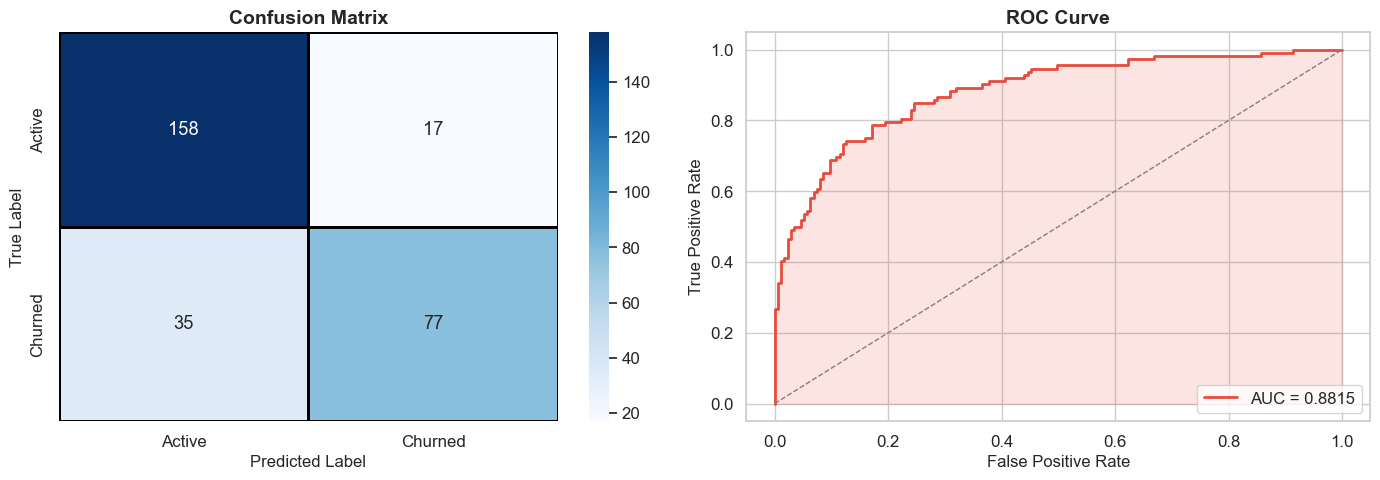

In [11]:
# ============================================================
# MODEL EVALUATION
# ============================================================

# Predictions on the test set
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print(f"✅ Test Accuracy: {acc:.2%}")
print(f"📊 AUC-ROC Score: {auc:.4f}")
print(f"\n📋 Classification Report:\n{classification_report(y_test, y_pred)}")

# --- Visualization: Confusion Matrix + ROC Curve ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Active', 'Churned'], yticklabels=['Active', 'Churned'],
            linewidths=1, linecolor='black')
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# Right: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#e74c3c')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right; font-size: 18px; line-height: 2;>

### 💾 حفظ الموديل (Saving the Model)
آخر خطوة! بنحفظ الموديل والـ Scaler بتاعه عشان نقدر نستخدمهم في الـ **Streamlit Web App** من غير ما نعيد التدريب كل مرة.

- `churn_model.pkl` — الموديل المدرّب
- `scaler.pkl` — أداة التوحيد اللي لازم نستخدمها على أي Input جديد

**مبروك! 🎉 كده خلصنا الـ EDA والـ ML Pipeline بالكامل!**

</div>

In [12]:
# ============================================================
# SAVE THE TRAINED MODEL AND SCALER
# ============================================================
import os

# Create the models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the best model using joblib
joblib.dump(best_model, 'models/churn_model.pkl')
print("✅ Model saved to: models/churn_model.pkl")

# Save the scaler (CRITICAL: must use the SAME scaler for predictions)
joblib.dump(scaler, 'models/scaler.pkl')
print("✅ Scaler saved to: models/scaler.pkl")

print("\n🚀 Ready for Streamlit deployment! Run: streamlit run streamlit_app.py")

✅ Model saved to: models/churn_model.pkl
✅ Scaler saved to: models/scaler.pkl

🚀 Ready for Streamlit deployment! Run: streamlit run streamlit_app.py
